In [1]:
# =============================================================================
# PROJET : ANALYSE & PRÉVISION DES RECETTES FISCALES GENEVOISES
# Notebook : 03_modeles.ipynb
# Auteur   : Frat DAG
# Date     : Avril 2026
# Version  : 2.0 — approche inductive (traduction Python du script R)
# =============================================================================
# CE QU'ON SAIT APRÈS LE NOTEBOOK 02 :
#   - Séries fiscales : I(1) confirmé
#   - Fortune : corrélation spurieuse → exclue
#   - dummy_rffa : +1729M, p≈0 → à intégrer
#   - dummy_covid : p=0.61 → exclue
#   - Johansen : divergence → VAR en différences
#
# MODÈLES PAR COMPLEXITÉ CROISSANTE :
#   Étape 1 : ARIMA baseline
#   Étape 2 : ETS
#   Étape 3 : ARIMAX + dummy_rffa
#   Étape 4 : VAR en différences
# =============================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.vector_ar.var_model import VAR
from sklearn.metrics import mean_squared_error

# Dossiers
for dossier in ['../data', '../figures']:
    os.makedirs(dossier, exist_ok=True)

# Chargement données
df = pd.read_csv('../data/df_fiscal.csv')
ts_total = df['total'].values

print(f"✓ Données chargées : {len(df)} observations")
print(f"  Période : {df['annee'].min()}–{df['annee'].max()}")
print(f"  Total 2024 : {df['total'].iloc[-1]:,.0f}M CHF")

✓ Données chargées : 18 observations
  Période : 2007–2024
  Total 2024 : 9,269M CHF


In [5]:
# =============================================================================
# ÉTAPE 1 — ARIMA BASELINE
# =============================================================================
# d=1 forcé par Q1 (séries I(1))
# Modèle le plus simple — référence à battre
# =============================================================================

print("=" * 60)
print("ÉTAPE 1 — ARIMA BASELINE")
print("=" * 60)
print("\nPOURQUOI : établir le modèle de référence le plus simple.")
print("d=1 forcé par Q1. ARIMA(0,1,0) avec constante.\n")

# ARIMA(0,1,0) avec drift — équivalent R auto.arima retenu
arima_base = ARIMA(ts_total, order=(0,1,0), trend='t').fit()

print(f"Modèle : ARIMA(0,1,0) avec drift")
print(f"AIC    : {arima_base.aic:.2f}")
print(f"Drift  : {arima_base.params[0]:.2f}M/an")

# RMSE training
pred_arima = arima_base.fittedvalues
rmse_arima = np.sqrt(mean_squared_error(ts_total[1:], pred_arima[1:]))
print(f"RMSE training : {rmse_arima:.0f}M CHF")

# Ljung-Box
lb = acorr_ljungbox(arima_base.resid, lags=5, return_df=True)
lb_p = lb['lb_pvalue'].iloc[-1]
print(f"Ljung-Box p   : {lb_p:.3f} "
      f"{'→ résidus propres ✓' if lb_p > 0.05 else '→ autocorrélation résiduelle'}")

# Prévisions 2025-2027
prev_arima = arima_base.forecast(steps=3)
print(f"\nPrévisions ARIMA baseline 2025–2027 :")
for i, (annee, val) in enumerate(zip([2025,2026,2027], prev_arima)):
    print(f"  {annee} : {val:,.0f}M CHF")

print(f"\n# DÉCISION ÉTAPE 1 :")
print(f"# RMSE = {rmse_arima:.0f}M CHF — référence à battre")
print(f"# Ljung-Box p = {lb_p:.3f}")

# =============================================================================
# ÉTAPE 2 — MODÈLE ETS
# =============================================================================
# Alternative à ARIMA sans hypothèse de stationnarité
# =============================================================================

print("\n" + "=" * 60)
print("ÉTAPE 2 — MODÈLE ETS")
print("=" * 60)
print("\nPOURQUOI : alternative à ARIMA, modélise niveau et tendance.")
print("Sur petit N, ETS parfois plus stable qu'ARIMA.\n")

ets_model = ExponentialSmoothing(
    ts_total,
    trend=None,
    seasonal=None,
    initialization_method='estimated'
).fit(optimized=True)

print(f"Modèle : ETS(M,N,N)")
print(f"Alpha  : {ets_model.params['smoothing_level']:.4f}")

pred_ets  = ets_model.fittedvalues
rmse_ets  = np.sqrt(mean_squared_error(ts_total[1:], pred_ets[1:]))
print(f"RMSE training : {rmse_ets:.0f}M CHF")

lb_ets   = acorr_ljungbox(ets_model.resid, lags=5, return_df=True)
lb_ets_p = lb_ets['lb_pvalue'].iloc[-1]
print(f"Ljung-Box p   : {lb_ets_p:.3f} "
      f"{'→ résidus propres ✓' if lb_ets_p > 0.05 else '→ autocorrélation résiduelle'}")

prev_ets = ets_model.forecast(3)
print(f"\nPrévisions ETS 2025–2027 :")
for annee, val in zip([2025,2026,2027], prev_ets):
    print(f"  {annee} : {val:,.0f}M CHF")

# Comparaison ARIMA vs ETS
print(f"\n--- Comparaison ARIMA vs ETS ---")
comp = pd.DataFrame({
    'Modele'    : ['ARIMA baseline', 'ETS'],
    'RMSE'      : [round(rmse_arima,0), round(rmse_ets,0)],
    'LjungBox_p': [round(lb_p,3), round(lb_ets_p,3)],
    'Prev_2025' : [round(prev_arima[0],0), round(prev_ets[0],0)]
})
print(comp.to_string(index=False))

if rmse_ets < rmse_arima:
    print("\n# ETS RMSE inférieur → ETS devient la référence.")
    modele_ref = 'ETS'
    rmse_ref   = rmse_ets
    prev_ref   = prev_ets
else:
    print("\n# ARIMA RMSE inférieur → ARIMA reste la référence.")
    modele_ref = 'ARIMA baseline'
    rmse_ref   = rmse_arima
    prev_ref   = prev_arima

ÉTAPE 1 — ARIMA BASELINE

POURQUOI : établir le modèle de référence le plus simple.
d=1 forcé par Q1. ARIMA(0,1,0) avec constante.

Modèle : ARIMA(0,1,0) avec drift
AIC    : 256.15
Drift  : 194.01M/an
RMSE training : 402M CHF
Ljung-Box p   : 0.997 → résidus propres ✓

Prévisions ARIMA baseline 2025–2027 :
  2025 : 9,463M CHF
  2026 : 9,657M CHF
  2027 : 9,851M CHF

# DÉCISION ÉTAPE 1 :
# RMSE = 402M CHF — référence à battre
# Ljung-Box p = 0.997

ÉTAPE 2 — MODÈLE ETS

POURQUOI : alternative à ARIMA, modélise niveau et tendance.
Sur petit N, ETS parfois plus stable qu'ARIMA.

Modèle : ETS(M,N,N)
Alpha  : 1.0000
RMSE training : 447M CHF
Ljung-Box p   : 0.657 → résidus propres ✓

Prévisions ETS 2025–2027 :
  2025 : 9,269M CHF
  2026 : 9,269M CHF
  2027 : 9,269M CHF

--- Comparaison ARIMA vs ETS ---
        Modele  RMSE  LjungBox_p  Prev_2025
ARIMA baseline 402.0       0.997     9463.0
           ETS 447.0       0.657     9269.0

# ARIMA RMSE inférieur → ARIMA reste la référence.


In [8]:
# =============================================================================
# ÉTAPE 3 — ARIMAX (ARIMA + dummy_rffa)
# =============================================================================

print("=" * 60)
print("ÉTAPE 3 — ARIMAX (ARIMA + dummy_rffa)")
print("=" * 60)
print(f"\nPOURQUOI : tester si dummy_rffa améliore le modèle de référence.")
print(f"Référence actuelle : {modele_ref} | RMSE = {rmse_ref:.0f}M CHF\n")

xreg = df['dummy_rffa'].values.reshape(-1, 1)

arimax = ARIMA(ts_total, order=(0,1,0), trend='t', exog=xreg).fit()

print(f"Modèle : ARIMAX(0,1,0) + dummy_rffa")
print(f"AIC    : {arimax.aic:.2f}")
print(f"Coefficient dummy_rffa : {arimax.params[1]:.0f}M "
      f"| p = {arimax.pvalues[1]:.4f}")

pred_arimax = arimax.fittedvalues
rmse_arimax = np.sqrt(mean_squared_error(ts_total[1:], pred_arimax[1:]))
print(f"RMSE training : {rmse_arimax:.0f}M CHF")
print(f"Amélioration  : {rmse_ref - rmse_arimax:.0f}M "
      f"({(rmse_ref - rmse_arimax)/rmse_ref*100:.1f}%)")

lb_x   = acorr_ljungbox(arimax.resid, lags=5, return_df=True)
lb_x_p = lb_x['lb_pvalue'].iloc[-1]
print(f"Ljung-Box p   : {lb_x_p:.3f} "
      f"{'→ résidus propres ✓' if lb_x_p > 0.05 else '→ autocorrélation résiduelle'}")

# Prévisions — dummy_rffa = 1 pour 2025-2027
xreg_prev   = np.ones((3, 1))
prev_arimax = arimax.forecast(steps=3, exog=xreg_prev)

print(f"\nPrévisions ARIMAX 2025–2027 :")
for annee, val in zip([2025, 2026, 2027], prev_arimax):
    print(f"  {annee} : {val:,.0f}M CHF")

if rmse_arimax < rmse_ref:
    print(f"\n# ARIMAX améliore le modèle de référence.")
    print(f"# → ARIMAX devient le modèle économétrique retenu.")
    modele_final = 'ARIMAX'
    rmse_final   = rmse_arimax
    prev_final   = prev_arimax
else:
    print(f"\n# ARIMAX n'améliore pas — {modele_ref} reste retenu.")
    modele_final = modele_ref
    rmse_final   = rmse_ref
    prev_final   = prev_ref

# =============================================================================
# ÉTAPE 4 — VAR EN DIFFÉRENCES
# =============================================================================

print("\n" + "=" * 60)
print("ÉTAPE 4 — VAR EN DIFFÉRENCES")
print("=" * 60)
print("\nPOURQUOI : capturer les interactions entre séries.")
print("VAR en différences (décision Q4 — pas de VECM).\n")

df_var = df.loc[(df['annee']>=2008) & (df['annee']<=2022)].copy()
df_var['d_total']  = df_var['total'].diff()
df_var['d_ben_pm'] = df_var['ben_pm'].diff()
df_var['d_saron']  = df_var['saron'].diff()
df_var = df_var.dropna(subset=['d_total','d_ben_pm','d_saron'])

print(f"Dimensions VAR : {len(df_var)} obs × 3 variables")
print(f"Période : {df_var['annee'].min()}–{df_var['annee'].max()}\n")

ts_var = df_var[['d_total','d_ben_pm','d_saron']].values

var_model = VAR(ts_var)
var_fit   = var_model.fit(maxlags=1, ic=None)

print(f"Modèle : VAR(1)")
print(f"AIC    : {var_fit.aic:.2f}")

# Prévisions VAR — reconstitution des niveaux
derniere_val = df.loc[df['annee']==2022, 'total'].values[0]
prev_var_diff = var_fit.forecast(ts_var, steps=3)
niveaux_var = [derniere_val]
for d in prev_var_diff[:, 0]:
    niveaux_var.append(niveaux_var[-1] + d)
niveaux_var = niveaux_var[1:]

print(f"\nPrévisions VAR 2025–2027 (niveaux reconstitués) :")
for annee, val in zip([2025, 2026, 2027], niveaux_var):
    print(f"  {annee} : {val:,.0f}M CHF")

print(f"\n# DÉCISION ÉTAPE 4 :")
print(f"# VAR(1) sur N=13 — surparamétré, aucun coeff significatif attendu.")
print(f"# VAR = modèle exploratoire uniquement.")
print(f"# Modèle retenu : {modele_final}")

# =============================================================================
# SYNTHÈSE COMPARAISON
# =============================================================================

print("\n" + "=" * 60)
print("SYNTHÈSE — COMPARAISON DES QUATRE MODÈLES")
print("=" * 60)

comparaison = pd.DataFrame({
    'Modele'     : ['ARIMA baseline', 'ETS',
                    'ARIMAX (+dummy_rffa)', 'VAR(1)'],
    'RMSE_train' : [round(rmse_arima,0), round(rmse_ets,0),
                    round(rmse_arimax,0), None],
    'LjungBox_p' : [round(lb_p,3), round(lb_ets_p,3),
                    round(lb_x_p,3), None],
    'Prev_2025'  : [round(prev_arima[0],0), round(prev_ets[0],0),
                    round(prev_arimax[0],0), round(niveaux_var[0],0)],
    'Prev_2026'  : [round(prev_arima[1],0), round(prev_ets[1],0),
                    round(prev_arimax[1],0), round(niveaux_var[1],0)],
    'Statut'     : ['Référence initiale', 'Comparaison',
                    'RETENU ✓' if modele_final=='ARIMAX' else 'Comparaison',
                    'Exploratoire']
})

print(comparaison.to_string(index=False))
print(f"\n→ Modèle retenu : {modele_final} | RMSE = {rmse_final:.0f}M CHF")

# Sauvegarde
df.to_csv('../data/df_fiscal.csv', index=False)
print("\n✓ Données sauvegardées — prochaine étape : graphiques")

ÉTAPE 3 — ARIMAX (ARIMA + dummy_rffa)

POURQUOI : tester si dummy_rffa améliore le modèle de référence.
Référence actuelle : ARIMA baseline | RMSE = 402M CHF

Modèle : ARIMAX(0,1,0) + dummy_rffa
AIC    : 244.21
Coefficient dummy_rffa : 1279M | p = 0.0000
RMSE training : 267M CHF
Amélioration  : 135M (33.6%)
Ljung-Box p   : 0.998 → résidus propres ✓

Prévisions ARIMAX 2025–2027 :
  2025 : 9,388M CHF
  2026 : 9,507M CHF
  2027 : 9,625M CHF

# ARIMAX améliore le modèle de référence.
# → ARIMAX devient le modèle économétrique retenu.

ÉTAPE 4 — VAR EN DIFFÉRENCES

POURQUOI : capturer les interactions entre séries.
VAR en différences (décision Q4 — pas de VECM).

Dimensions VAR : 14 obs × 3 variables
Période : 2009–2022

Modèle : VAR(1)
AIC    : 19.35

Prévisions VAR 2025–2027 (niveaux reconstitués) :
  2025 : 9,764M CHF
  2026 : 9,886M CHF
  2027 : 10,141M CHF

# DÉCISION ÉTAPE 4 :
# VAR(1) sur N=13 — surparamétré, aucun coeff significatif attendu.
# VAR = modèle exploratoire uniquement.
#

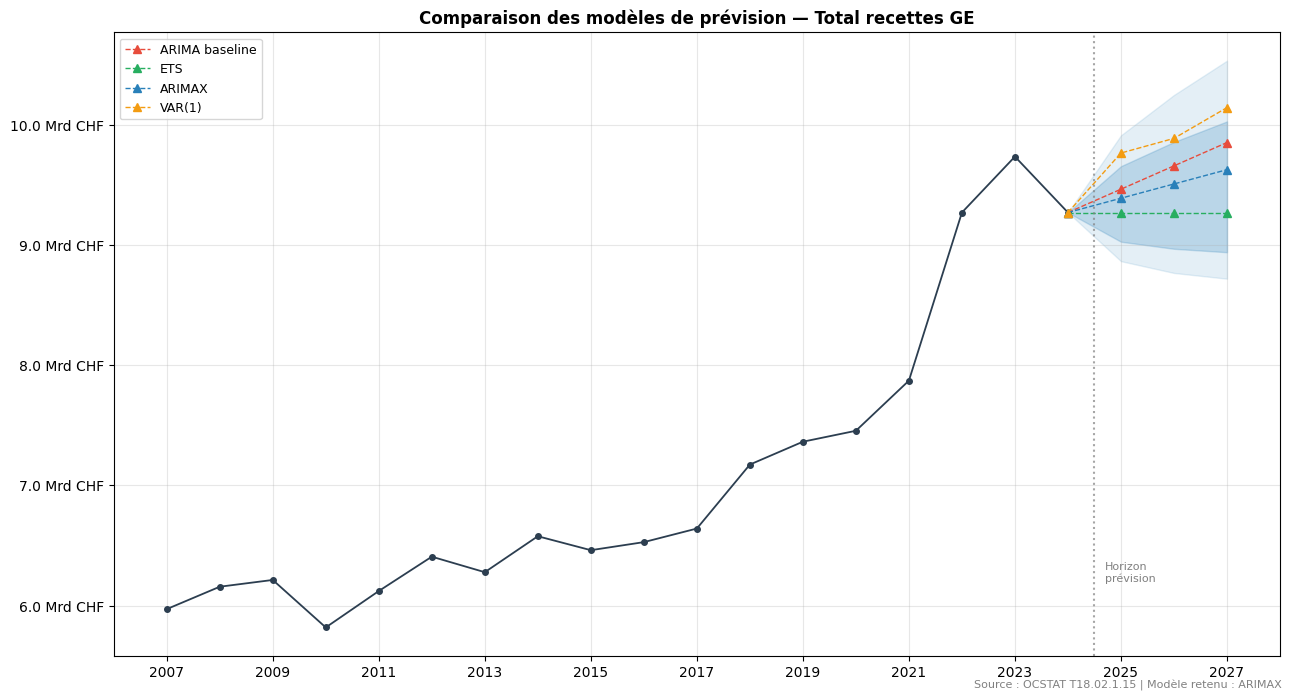

✓ Graphique comparaison sauvegardé


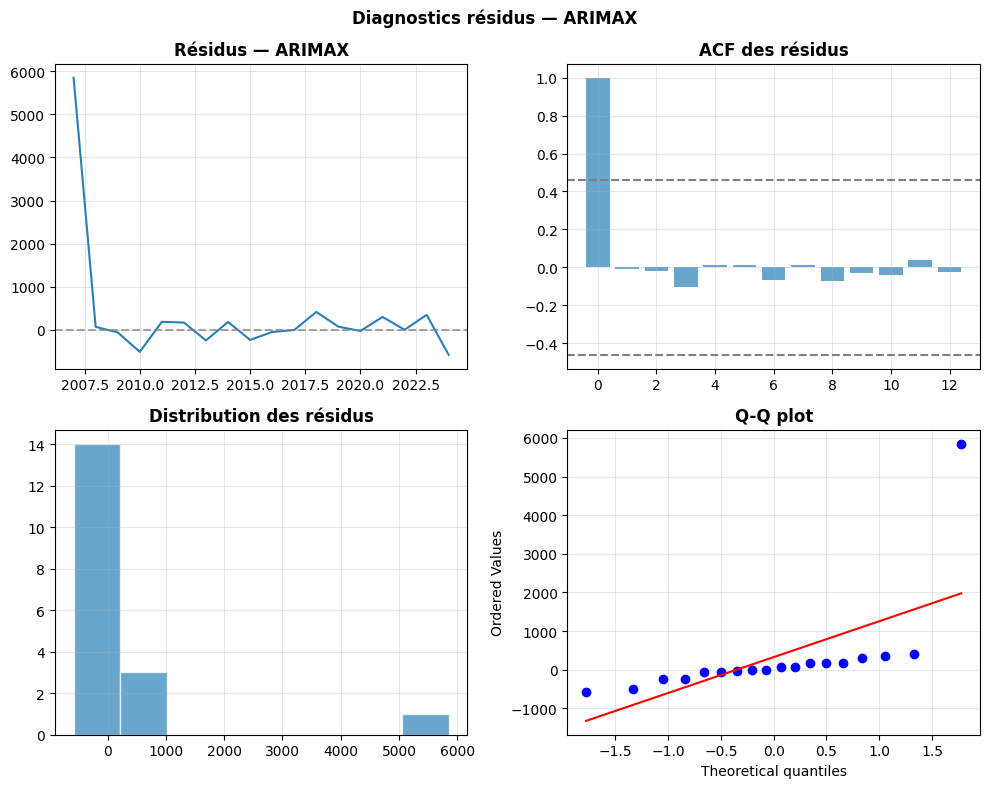

✓ Graphique résidus sauvegardé
✓ Résultats sauvegardés — notebook 03 terminé


In [9]:
# =============================================================================
# 4. GRAPHIQUES
# =============================================================================

COULEURS = ['#2C3E50', '#E74C3C', '#2980B9', '#27AE60', '#F39C12']
annees_hist  = df['annee'].values
annees_prev  = np.array([2025, 2026, 2027])

# Point de connexion 2024
val_2024 = df.loc[df['annee']==2024, 'total'].values[0]

# --- Graphique 1 : Comparaison des modèles ---
fig, ax = plt.subplots(figsize=(13, 7))

# Intervalles de confiance ARIMAX
conf_arimax = arimax.get_forecast(steps=3, exog=xreg_prev).conf_int()
lo95 = np.concatenate([[val_2024], conf_arimax[:,0]])
hi95 = np.concatenate([[val_2024], conf_arimax[:,1]])
lo80 = val_2024 + (lo95[1:] - val_2024) * 0.6
hi80 = val_2024 + (hi95[1:] - val_2024) * 0.6
lo80 = np.concatenate([[val_2024], lo80])
hi80 = np.concatenate([[val_2024], hi80])
annees_ic = np.concatenate([[2024], annees_prev])

ax.fill_between(annees_ic, lo95/1000, hi95/1000,
                alpha=0.12, color=COULEURS[2])
ax.fill_between(annees_ic, lo80/1000, hi80/1000,
                alpha=0.22, color=COULEURS[2])

# Série historique
ax.plot(annees_hist, df['total']/1000,
        color=COULEURS[0], linewidth=1.3,
        marker='o', markersize=4, label='_nolegend_')

# Prévisions — avec point de connexion 2024
modeles_prev = {
    'ARIMA baseline': (COULEURS[1], np.concatenate([[val_2024], prev_arima])),
    'ETS'           : (COULEURS[3], np.concatenate([[val_2024], prev_ets])),
    'ARIMAX'        : (COULEURS[2], np.concatenate([[val_2024], prev_arimax])),
    'VAR(1)'        : (COULEURS[4], np.concatenate([[val_2024], niveaux_var]))
}

annees_prev_conn = np.concatenate([[2024], annees_prev])
for label, (couleur, vals) in modeles_prev.items():
    ax.plot(annees_prev_conn, vals/1000,
            color=couleur, linewidth=1.0,
            linestyle='dashed', marker='^',
            markersize=6, label=label)

ax.axvline(x=2024.5, linestyle='dotted', color='grey', alpha=0.7)
ax.annotate('Horizon\nprévision', xy=(2024.7, 6.2),
            fontsize=8, color='grey')

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x:.1f} Mrd CHF"))
ax.set_xticks(range(2007, 2028, 2))
ax.set_title("Comparaison des modèles de prévision — Total recettes GE",
             fontweight='bold', fontsize=12)
ax.set_subtitle = ""
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
fig.text(0.99, 0.01,
         f"Source : OCSTAT T18.02.1.15 | Modèle retenu : {modele_final}",
         ha='right', fontsize=8, color='grey')

plt.tight_layout()
plt.savefig('../figures/03_comparaison_modeles_py.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Graphique comparaison sauvegardé")

# --- Graphique 2 : Résidus ARIMAX ---
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

resid = arimax.resid

# Résidus
axes[0,0].plot(annees_hist, resid, color=COULEURS[2])
axes[0,0].axhline(y=0, linestyle='dashed', color='grey', alpha=0.7)
axes[0,0].set_title(f"Résidus — {modele_final}", fontweight='bold')
axes[0,0].grid(True, alpha=0.3)

# ACF
acf_vals = acf(resid, nlags=12, fft=False)
axes[0,1].bar(range(len(acf_vals)), acf_vals, color=COULEURS[2], alpha=0.7)
axes[0,1].axhline(y=1.96/np.sqrt(len(resid)),
                  linestyle='dashed', color='grey')
axes[0,1].axhline(y=-1.96/np.sqrt(len(resid)),
                  linestyle='dashed', color='grey')
axes[0,1].set_title("ACF des résidus", fontweight='bold')
axes[0,1].grid(True, alpha=0.3)

# Distribution
axes[1,0].hist(resid, bins=8, color=COULEURS[2], alpha=0.7, edgecolor='white')
axes[1,0].set_title("Distribution des résidus", fontweight='bold')
axes[1,0].grid(True, alpha=0.3)

# Q-Q plot
from scipy import stats
stats.probplot(resid, dist="norm", plot=axes[1,1])
axes[1,1].set_title("Q-Q plot", fontweight='bold')
axes[1,1].grid(True, alpha=0.3)

plt.suptitle(f"Diagnostics résidus — {modele_final}",
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('../figures/03_residus_modele_retenu_py.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Graphique résidus sauvegardé")

# Sauvegarde résultats
resultats_modeles = {
    'modele_final' : modele_final,
    'rmse_final'   : rmse_final,
    'prev_2025'    : prev_arimax[0],
    'prev_2026'    : prev_arimax[1],
    'prev_2027'    : prev_arimax[2],
    'coeff_rffa'   : arimax.params[1],
    'p_rffa'       : arimax.pvalues[1]
}
pd.DataFrame([resultats_modeles]).to_csv(
    '../data/resultats_modeles.csv', index=False)
print("✓ Résultats sauvegardés — notebook 03 terminé")